Propeller  RPM  n (rev/s)     J    CT    CQ  Thrust (N)  Torque (Nm)  Power (W)  Efficiency
  APC 9x6 4000      66.67 0.656 0.055 0.010       0.818       0.0340      14.24       0.574
  APC 9x6 5000      83.33 0.525 0.070 0.012       1.626       0.0637      33.37       0.487
  APC 9x6 6000     100.00 0.437 0.082 0.014       2.743       0.1071      67.27       0.408
 APC 10x7 4000      66.67 0.591 0.060 0.011       1.360       0.0633      26.52       0.513
 APC 10x7 5000      83.33 0.472 0.075 0.013       2.656       0.1169      61.22       0.434
 APC 10x7 6000     100.00 0.394 0.090 0.016       4.589       0.2072     130.20       0.352


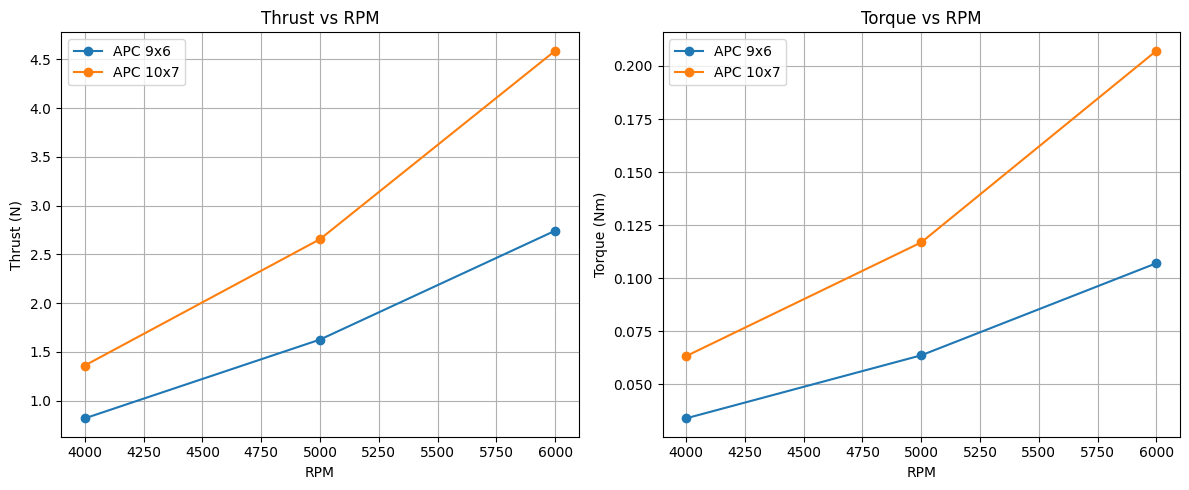

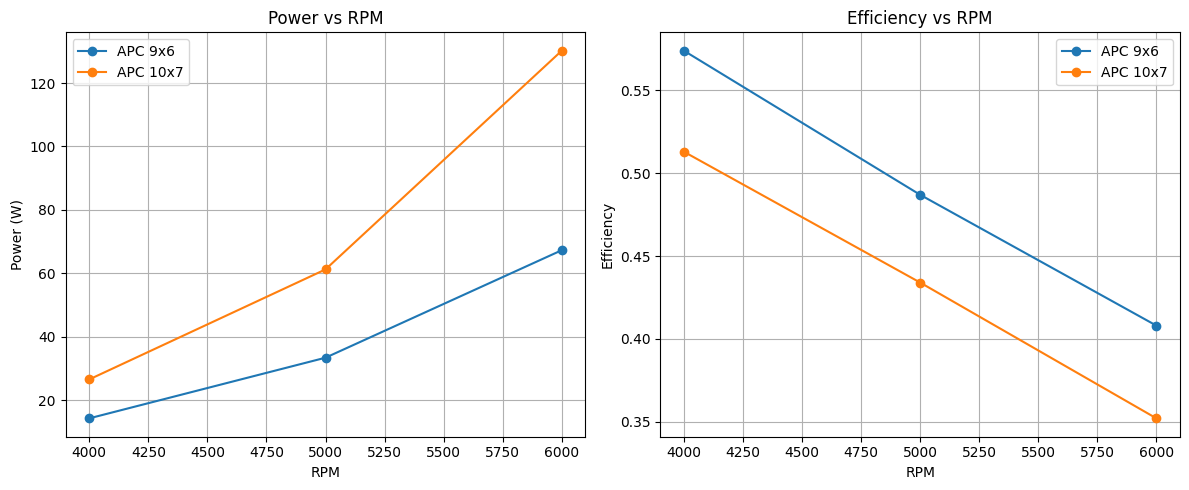

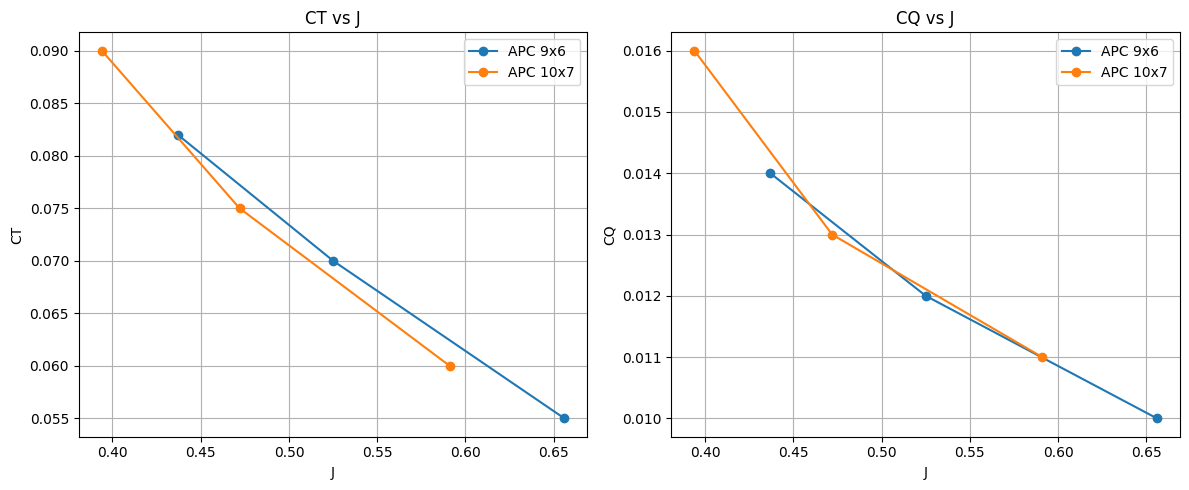

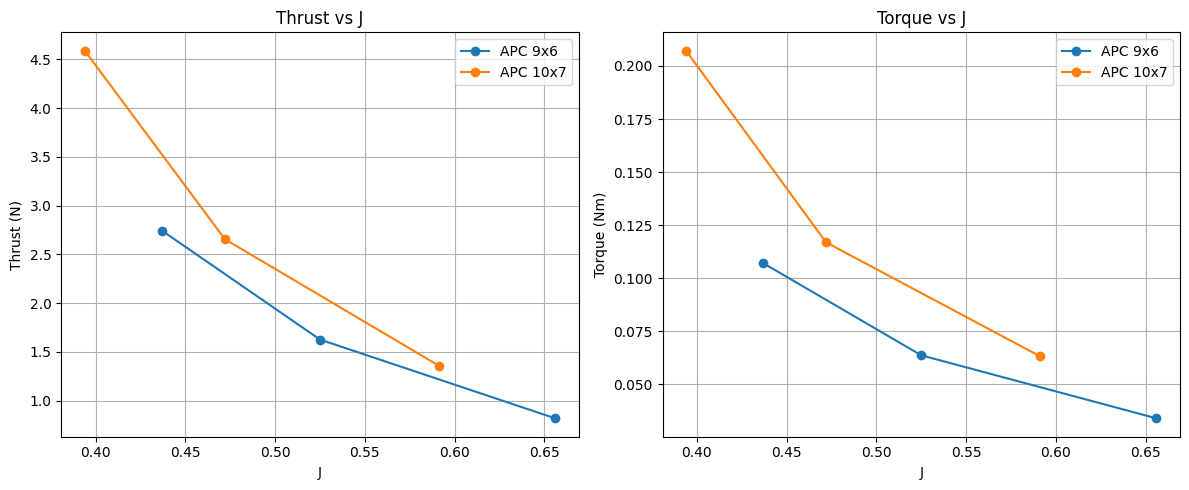

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rho = 1.225
V = 10
RPM_values = [4000, 5000, 6000]

props = {
    "APC 9x6": {
        "D": 9 * 0.0254,
        "CT": [0.055, 0.070, 0.082],
        "CQ": [0.010, 0.012, 0.014]
    },
    "APC 10x7": {
        "D": 10 * 0.0254,
        "CT": [0.060, 0.075, 0.090],
        "CQ": [0.011, 0.013, 0.016]
    }
}
def compute(name, data):
    D = data["D"]
    CT_list = data["CT"]
    CQ_list = data["CQ"]
    rows = []
    for i, rpm in enumerate(RPM_values):
        n = rpm / 60
        J = V / (n * D)
        CT = CT_list[i]
        CQ = CQ_list[i]
        T = CT * rho * (n**2) * (D**4)
        Q = CQ * rho * (n**2) * (D**5)
        P = 2 * np.pi * n * Q
        eta = min((T * V) / P, 1)
        rows.append({
            "Propeller": name,
            "RPM": rpm,
            "n (rev/s)": n,
            "J": J,
            "CT": CT,
            "CQ": CQ,
            "Thrust (N)": T,
            "Torque (Nm)": Q,
            "Power (W)": P,
            "Efficiency": eta
        })
    return pd.DataFrame(rows)
df = pd.concat([compute(name, data) for name, data in props.items()], ignore_index=True)
df = df.round({
    "n (rev/s)": 2,
    "J": 3,
    "Thrust (N)": 3,
    "Torque (Nm)": 4,
    "Power (W)": 2,
    "Efficiency": 3
})
pd.set_option('display.max_columns', None)
print(df.to_string(index=False))
df9 = df[df["Propeller"] == "APC 9x6"]
df10 = df[df["Propeller"] == "APC 10x7"]
df9s = df9.sort_values("J")
df10s = df10.sort_values("J")

fig, axs = plt.subplots(1, 2, figsize=(12,5))

axs[0].plot(df9["RPM"], df9["Thrust (N)"], marker='o', label="APC 9x6")
axs[0].plot(df10["RPM"], df10["Thrust (N)"], marker='o', label="APC 10x7")
axs[0].set_xlabel("RPM")
axs[0].set_ylabel("Thrust (N)")
axs[0].set_title("Thrust vs RPM")
axs[0].legend()
axs[0].grid()

axs[1].plot(df9["RPM"], df9["Torque (Nm)"], marker='o', label="APC 9x6")
axs[1].plot(df10["RPM"], df10["Torque (Nm)"], marker='o', label="APC 10x7")
axs[1].set_xlabel("RPM")
axs[1].set_ylabel("Torque (Nm)")
axs[1].set_title("Torque vs RPM")
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12,5))

axs[0].plot(df9["RPM"], df9["Power (W)"], marker='o', label="APC 9x6")
axs[0].plot(df10["RPM"], df10["Power (W)"], marker='o', label="APC 10x7")
axs[0].set_xlabel("RPM")
axs[0].set_ylabel("Power (W)")
axs[0].set_title("Power vs RPM")
axs[0].legend()
axs[0].grid()

axs[1].plot(df9["RPM"], df9["Efficiency"], marker='o', label="APC 9x6")
axs[1].plot(df10["RPM"], df10["Efficiency"], marker='o', label="APC 10x7")
axs[1].set_xlabel("RPM")
axs[1].set_ylabel("Efficiency")
axs[1].set_title("Efficiency vs RPM")
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12,5))

axs[0].plot(df9s["J"], df9s["CT"], marker='o', label="APC 9x6")
axs[0].plot(df10s["J"], df10s["CT"], marker='o', label="APC 10x7")
axs[0].set_xlabel("J")
axs[0].set_ylabel("CT")
axs[0].set_title("CT vs J")
axs[0].legend()
axs[0].grid()

axs[1].plot(df9s["J"], df9s["CQ"], marker='o', label="APC 9x6")
axs[1].plot(df10s["J"], df10s["CQ"], marker='o', label="APC 10x7")
axs[1].set_xlabel("J")
axs[1].set_ylabel("CQ")
axs[1].set_title("CQ vs J")
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12,5))

axs[0].plot(df9s["J"], df9s["Thrust (N)"], marker='o', label="APC 9x6")
axs[0].plot(df10s["J"], df10s["Thrust (N)"], marker='o', label="APC 10x7")
axs[0].set_xlabel("J")
axs[0].set_ylabel("Thrust (N)")
axs[0].set_title("Thrust vs J")
axs[0].legend()
axs[0].grid()

axs[1].plot(df9s["J"], df9s["Torque (Nm)"], marker='o', label="APC 9x6")
axs[1].plot(df10s["J"], df10s["Torque (Nm)"], marker='o', label="APC 10x7")
axs[1].set_xlabel("J")
axs[1].set_ylabel("Torque (Nm)")
axs[1].set_title("Torque vs J")
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()